In [1]:
# from autocvd import autocvd
# autocvd(num_gpus = 1, interval=1)
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

from functools import partial

# timing and progress bars
from timeit import default_timer as timer
from tqdm import tqdm
import pickle
import corner
from matplotlib import pyplot as plt
import numpy as np

# numerics
import jax
import jax.numpy as jnp
import optimistix as optx
import equinox as eqx
import flax
import optax

from jax import jit

from flow_CrossAttentionSetTransformer import Flow
from dataloader import OdisseoOTAllParametersPosition_newprior
from sampler import ODESolver



In [12]:
dataloader_train = OdisseoOTAllParametersPosition_newprior(
            DATA_ROOT = '/export/data/vgiusepp/odisseo_data/data_varying_position_newprior/sbi_sim/data/sbi-benchmarks/odisseo_AllParametersPosition_newprior',
            num_samples= 100_000,
            split= [0, 94999],
            seed= 0,
            num_steps = 2000,
            batch_size = 32,
            use_jax = False)

SEED = 42
dim_flow = 13
N_dim = 128
N_head = 4
depth = 3

key = jax.random.PRNGKey(SEED)
key, subkey = jax.random.split(key, 2)
flow = Flow(dim_flow=dim_flow,
            N_dim=N_dim,
            N_head=N_head, 
            depth=depth, 
            sample_size=1000,
            ln=False,)

flow_params = flow.init_weights(subkey)

import orbax
# Load Orbax checkpoint
checkpoint_dir = '/export/home/vgiusepp/sbi_diff_sim/sbi-sim/flow_matching_personal/CrossAttentionTransformer/checkpoint_1/'

try:
    # # Create Orbax checkpointer
    # checkpointer = orbax.checkpoint.PyTreeCheckpointer()
    
    # # Restore checkpoint with target structure
    # best_params = checkpointer.restore(checkpoint_dir, item=flow_params)
    from flax.training.checkpoints import restore_checkpoint

    best_params = restore_checkpoint(checkpoint_dir, target=flow_params)

    # Verify parameters were loaded
    param_count = sum(x.size for x in jax.tree_util.tree_leaves(best_params))
    print(f"Successfully loaded {param_count} parameters from Orbax checkpoint")
    
except Exception as e:
    print(f"Failed to load Orbax checkpoint: {e}")
    print("Using fresh parameters")
    best_params = flow_params


key = jax.random.PRNGKey(0)
t = jnp.linspace(0, 1, 1).reshape(-1, 1)
theta = jax.random.normal(key, (1, 13))
x_obs = jax.random.normal(key, (1, 1000, 6))
flow.apply({'params': best_params}, timesteps=t, sample=theta, encoder_hidden_states=x_obs)

odisseo_AllParametersPosition_newprior
DATA_ROOT: /export/data/vgiusepp/odisseo_data/data_varying_position_newprior/sbi_sim/data/sbi-benchmarks/odisseo_AllParametersPosition_newprior/
Loading odisseo_AllParametersPosition_newprior locally from existing directory /export/data/vgiusepp/odisseo_data/data_varying_position_newprior/sbi_sim/data/sbi-benchmarks/odisseo_AllParametersPosition_newprior
Dataloader sampling without replacements (num_steps: 2969)


Successfully loaded 2027661 parameters from Orbax checkpoint


Array([[ 1.39084256e+08,  7.26755840e+07,  7.67629120e+07,
         1.09443864e+08,  1.33509280e+08, -6.10539880e+07,
         3.84524288e+08,  1.38426512e+08,  6.06511600e+06,
        -4.99545480e+07,  3.81473520e+07,  4.86937680e+07,
         7.13105520e+07]], dtype=float32)

In [13]:
num_samples = 200
key, rng = jax.random.split(key)
solver = ODESolver()
dictionary_sampling, _ = solver.sample(num_samples=num_samples, 
                                       dim=dim_flow, model=flow, 
                                       params={'params': best_params}, 
                                       rng=rng, conditioning=x_obs.repeat(num_samples, axis=0), 
                                       z_init=None )

samples = dictionary_sampling['samples']

num_samples = 300
batch_size = 100
num_samples_batched = [num_samples/(num_samples//batch_size) for _ in range(batch_size)]

In [14]:
# Simple inline version
num_samples = 400
batch_size = 200
all_samples = []

num_batches = (num_samples + batch_size - 1) // batch_size

for i in range(num_batches):
    # Calculate batch size for this iteration
    remaining_samples = num_samples - i * batch_size
    current_batch_size = min(batch_size, remaining_samples)
    
    # Split RNG
    rng, batch_rng = jax.random.split(rng)
    
    # Sample this batch
    dictionary_sampling, _ = solver.sample(
        num_samples=current_batch_size,
        dim=dim_flow,
        model=flow,
        params={'params': best_params},
        rng=batch_rng,
        conditioning=x_obs.repeat(current_batch_size, axis=0),
        z_init=None
    )
    
    # Collect samples
    all_samples.append(dictionary_sampling['samples'])

# Concatenate all samples
samples = jnp.concatenate(all_samples, axis=0)
print(f"Final samples shape: {samples.shape}")

Final samples shape: (400, 13)


In [15]:
samples

Array([[-2.22580626e+18, -5.16413605e+17, -1.02324435e+17, ...,
         2.81514473e+17, -3.61294324e+16, -3.69765245e+17],
       [-1.40510893e+18, -3.21490706e+17, -6.04698281e+16, ...,
         1.77481638e+17, -2.31557707e+16, -2.29172308e+17],
       [-3.72418772e+18, -8.78943754e+17, -1.90291481e+17, ...,
         4.72296457e+17, -5.56151450e+16, -6.38752415e+17],
       ...,
       [-1.07112100e+18, -2.43719414e+17, -4.79892501e+16, ...,
         1.35935878e+17, -1.23679854e+16, -1.82429887e+17],
       [-7.25824390e+17, -1.62119399e+17, -3.24616592e+16, ...,
         9.24941136e+16, -3.01689616e+15, -1.30651608e+17],
       [-3.66791829e+18, -8.48742437e+17, -1.81150124e+17, ...,
         4.64891211e+17, -5.46620273e+16, -6.21991941e+17]],      dtype=float32)

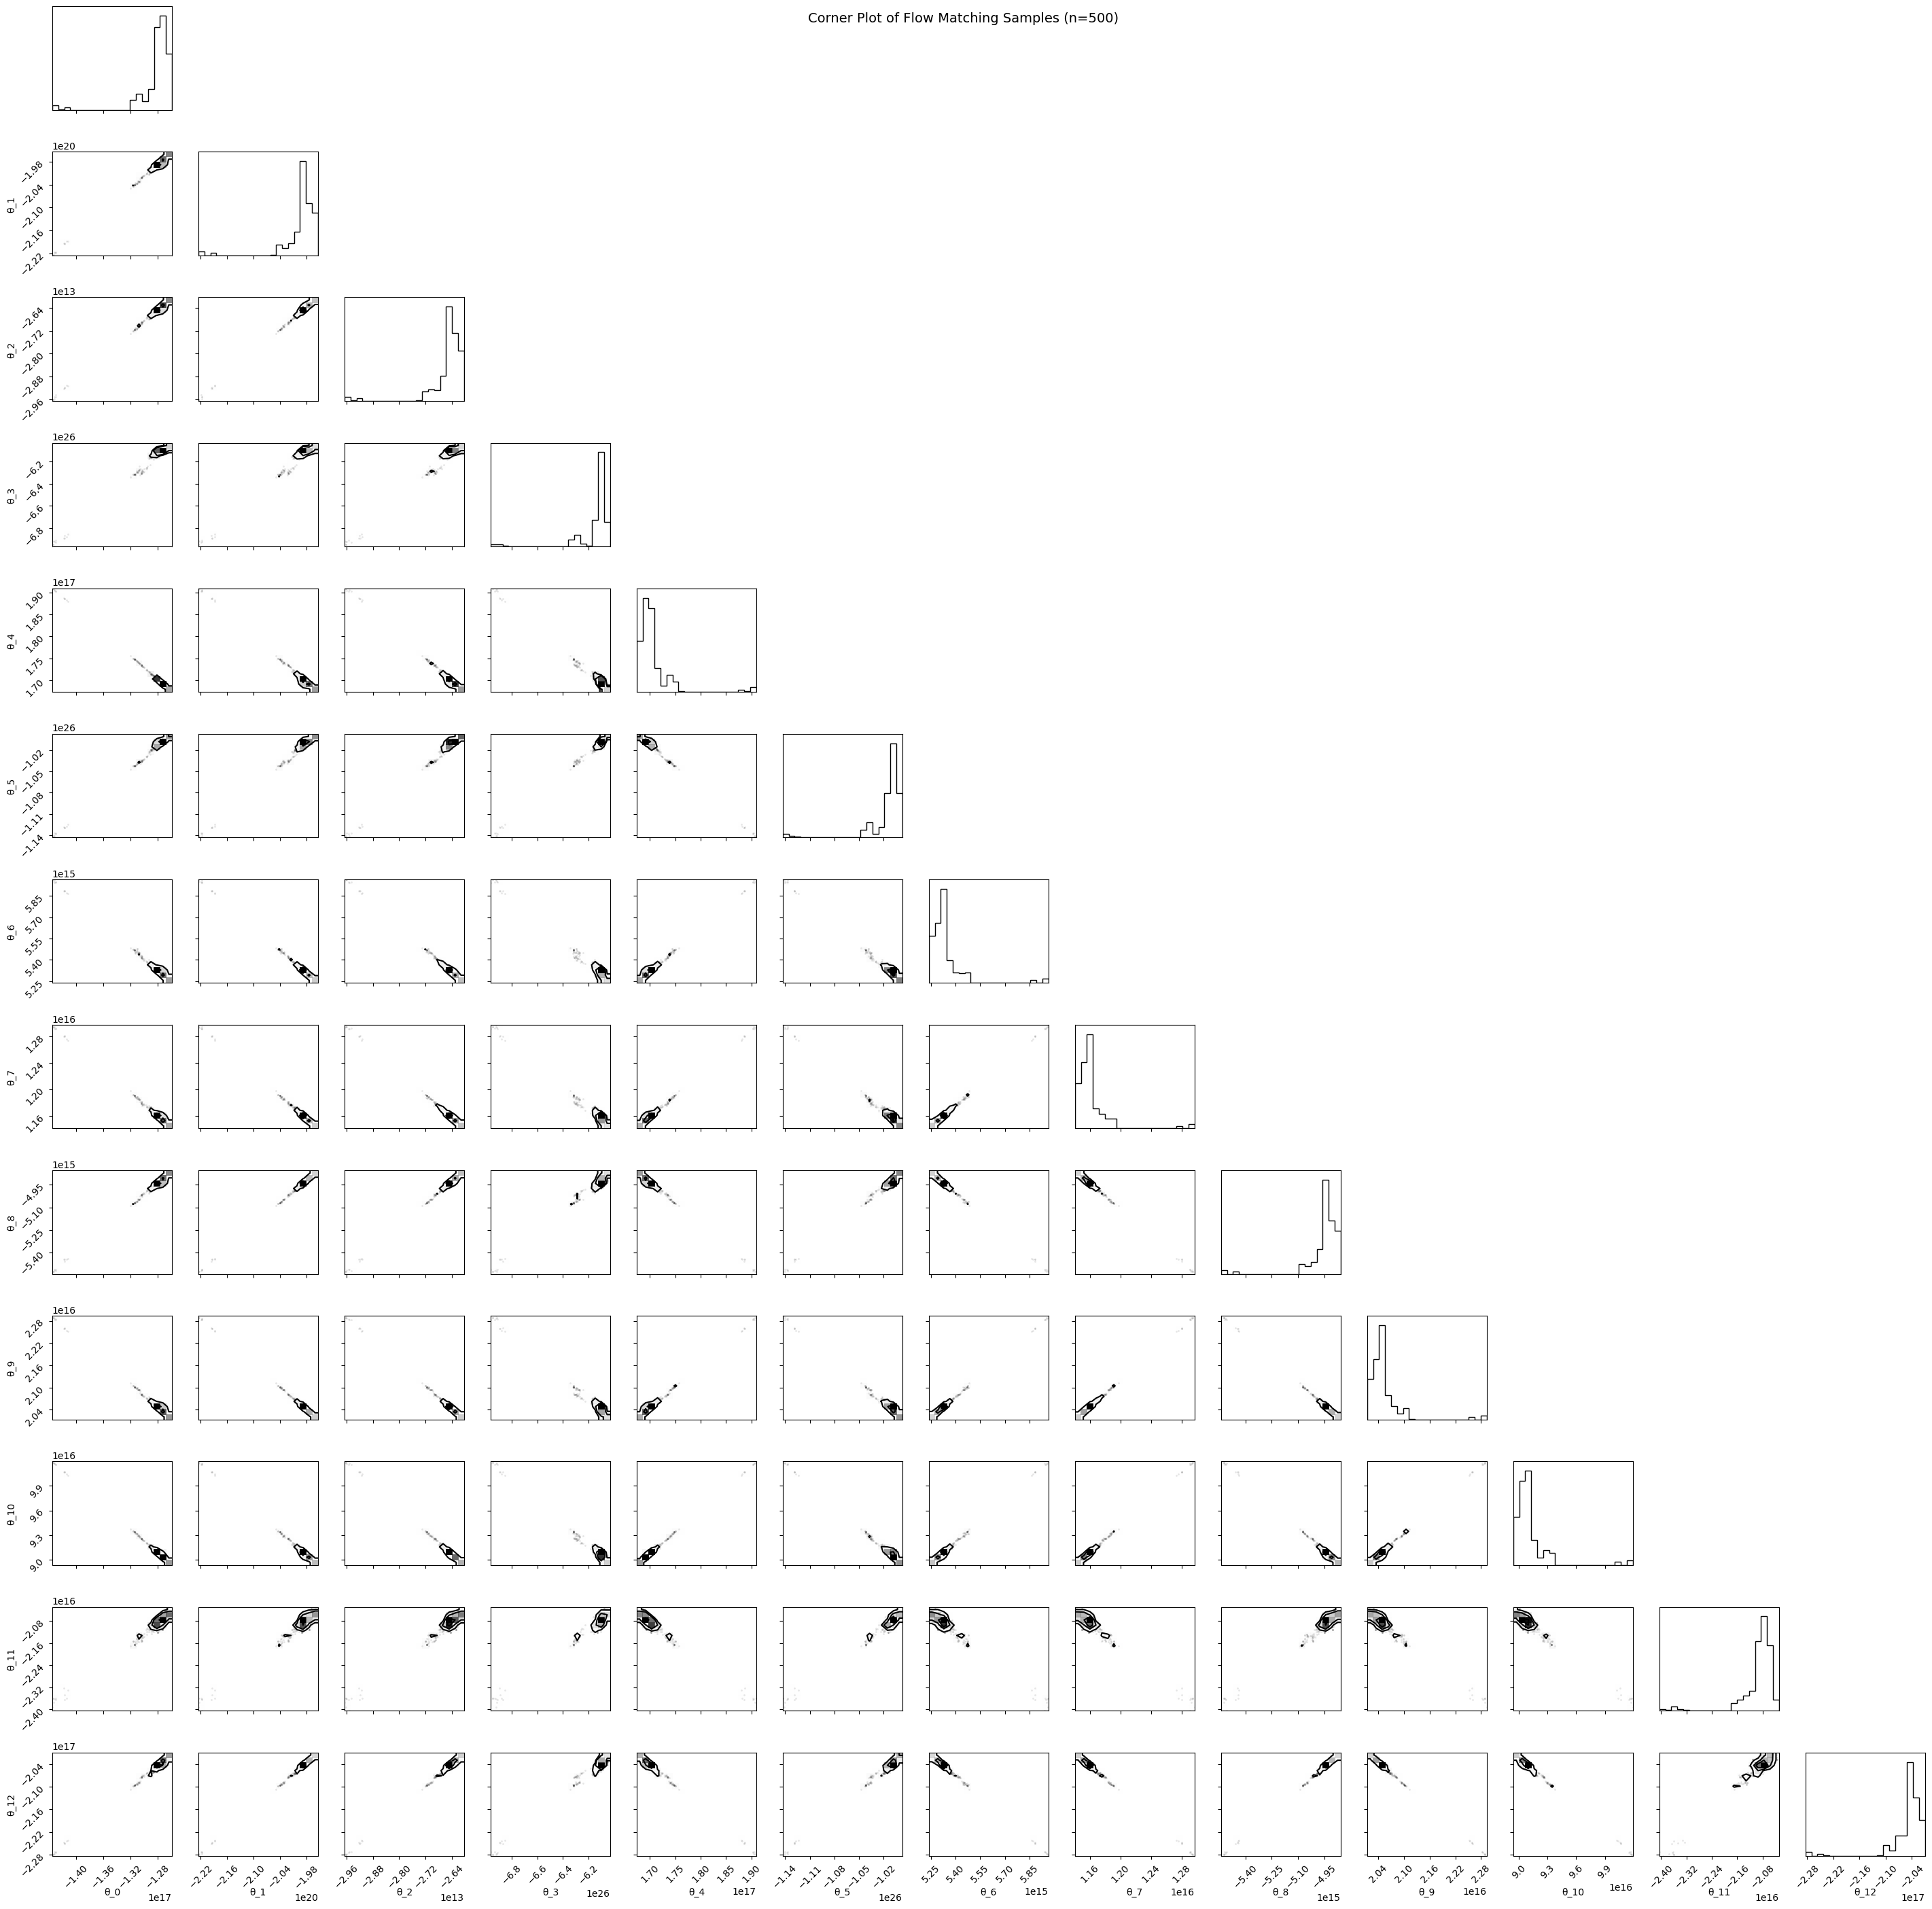

In [16]:
num_samples = 500
for id in [1]:
    observation, true_theta, reference_posterior = dataloader_train.get_observation(id)
    dictionary_sampling, _ = solver.sample(num_samples=num_samples, 
                                           dim=dim_flow, 
                                           model=flow, 
                                           params={'params': best_params}, 
                                           rng=rng, 
                                           conditioning=observation.repeat(num_samples, axis=0), 
                                           z_init=None )
    samples = dictionary_sampling['samples']

    samples = np.array(samples)
    samples = samples * dataloader_train.std_X + dataloader_train.mean_X  # Unnormalize samples
    # Create corner plot
    fig = corner.corner(
        samples, 
        labels=[f'θ_{i}' for i in range(dim_flow)],  # Parameter labels θ_0, θ_1, ..., θ_12
    )
    corner.overplot_lines(fig, true_theta[0], color="C1")
    corner.overplot_points(fig, true_theta, marker="s", color="C1")

    plt.suptitle(f'Corner Plot of Flow Matching Samples (n={num_samples})', fontsize=14, y=0.98)
    plt.tight_layout()
    plt.show();

In [7]:
from abc import ABC, abstractmethod
from typing import Iterable, Tuple

import jax.random as jr
import os

from typing import Tuple, List, Optional

import tarp



class Callback(ABC):

    name: str

    @abstractmethod
    def __call__(self, logs: dict, rng: jr.PRNGKey, *args, **kwargs) \
            -> Tuple[dict, jr.PRNGKey]:
        pass

    def on_test(self, logs: dict, rng: jr.PRNGKey, *args, **kwargs):
        return logs, rng

    def on_train_begin(self, logs: dict, rng: jr.PRNGKey, *args, **kwargs):
        return logs, rng

    def on_train_end(self, logs: dict, rng: jr.PRNGKey, *args, **kwargs):
        return logs, rng

    def on_epoch_begin(self, logs: dict, rng: jr.PRNGKey, *args, **kwargs):
        return logs, rng

    def on_epoch_end(self, logs: dict, rng: jr.PRNGKey, *args, **kwargs):
        return logs, rng
    
class C2ST_OT_AllParametersPositions_newprior(Callback):

    name: str = 'rankss'
    save_every: int = 0

    # observation_idx: List[int] = [i for i in range(1, observation_idx)]
    num_total_samples: int = 1_000
    # batch_size: int = 1_000

    def __init__(self, save_every: int = 0, savedir: str = None, num_total_samples: int = 1_000, observation_idx: int = 10, batch_size: int = 1_000):
        super().__init__()
        self.save_every = save_every
        self.savedir = savedir
        self.num_total_samples = num_total_samples
        self.observation_idx = [i for i in range(1, observation_idx)]
        self.batch_size = batch_size
        self.labels = ['$t_{end}$', '$M_{plummer}$', '$a_{plummer}$', '$M_{NFW}$', '$r_{NFW}$', '$M_{MN}$', '$a_{MN}$', '$x$', '$y$', '$z$', '$v_x$', '$v_y$', '$v_z$']
        if self.savedir is not None:
            os.makedirs(self.savedir + '/pictures', exist_ok=True)
        
    def __call__(self, logs: dict, rng: jr.PRNGKey, *args, **kwargs):
        return self._call(logs, rng, *args, **kwargs)

    def _call(self, logs: dict, rng: jr.PRNGKey, strategy,
              train_loader , *args, **kwargs) \
            -> Tuple[dict, jr.PRNGKey]:

        
        figure_list = []
        fig, axes = plt.subplots(1, 4, figsize=(30, 5))  # Create figure and 4 axes once

        true_theta_test_set = np.zeros((len(self.observation_idx), 13))
        predicted_theta_test_set = np.zeros((self.num_total_samples, len(self.observation_idx), 13))

        for id in tqdm(self.observation_idx):

            observation, true_theta, reference_posterior = train_loader.get_observation(id)
            true_theta_test_set[id-1, :] = true_theta[0, :]

            # observation = jnp.array(observation).repeat(self.num_total_samples, axis=0)
            # Simple inline version
            num_samples = self.num_total_samples
            batch_size = self.batch_size
            all_samples = []

            num_batches = (num_samples + batch_size - 1) // batch_size

            for i in range(num_batches):
                # Calculate batch size for this iteration
                remaining_samples = num_samples - i * batch_size
                current_batch_size = min(batch_size, remaining_samples)
                
                # Split RNG
                rng, batch_rng = jax.random.split(rng)
                
                # Sample this batch
                dictionary_sampling, _ = solver.sample(
                    num_samples=current_batch_size,
                    dim=dim_flow,
                    model=flow,
                    params={'params': best_params},
                    rng=batch_rng,
                    conditioning=observation.repeat(current_batch_size, axis=0),
                    z_init=None
                )
                
                # Collect samples
                all_samples.append(dictionary_sampling['samples'])

            posterior_samples = dictionary_sampling['samples']
            # Concatenate all samples
            posterior_samples = jnp.concatenate(all_samples, axis=0)
        posterior_samples= posterior_samples * train_loader.std_X + train_loader.mean_X
        predicted_theta_test_set[:, id-1, :] = posterior_samples
        print(f"Predicted theta shape: {predicted_theta_test_set.shape}")
        print(f'true_theta_test_set: {true_theta_test_set.shape}')


        

        rank_plot = self._plot_ranks_histogram(
            samples=predicted_theta_test_set,
            trues=true_theta_test_set,
            nbins=10)
        
        coverage_plot = self._plot_coverage(
            samples=predicted_theta_test_set,
            trues=true_theta_test_set,
            plotscatter=True,
        )

        prediction_plot = self._plot_predictions(
            samples=predicted_theta_test_set,
            trues=true_theta_test_set,
        )

        tarp_plot = self._plot_TARP(
            posterior_samples=predicted_theta_test_set,
            theta=true_theta_test_set,
        )
        
        figure_list.append(rank_plot)
        figure_list.append(coverage_plot)
        figure_list.append(prediction_plot)

        if self.savedir is not None:
                rank_plot.savefig(f"{self.savedir}/pictures/ranks_histogram.pdf")
                coverage_plot.savefig(f"{self.savedir}/pictures/coverage_plot.pdf")
                prediction_plot.savefig(f"{self.savedir}/pictures/prediction_plot.pdf")
                tarp_plot.savefig(f"{self.savedir}/pictures/tarp_plot.pdf")

        figure_list.append(fig)

        np.savez(f"{self.savedir}/pictures/predicted_theta_test_set.npz",
                 predicted_theta=predicted_theta_test_set,
                 true_theta=true_theta_test_set)

        for fig in figure_list:
            plt.close(fig)

        return logs, rng
    
    def on_test(self, logs: dict, rng: jr.PRNGKey, *args, **kwargs):
            return self.__call__(logs, rng, *args, **kwargs)
    
    def _get_ranks(
            self,
            samples: np.array,
            trues: np.array,
        ) -> np.array:
            """Get the marginal ranks of the true parameters in the posterior samples.

            Args:
                samples (np.array): posterior samples of shape (nsamples, ndata, npars)
                trues (np.array): true parameters of shape (ndata, npars)

            Returns:
                np.array: ranks of the true parameters in the posterior samples 
                    of shape (ndata, npars)
            """
            ranks = (samples < trues[None, ...]).sum(axis=0)
            return ranks


    def _plot_ranks_histogram(
            self, samples: np.ndarray, trues: np.ndarray, nbins: int = 10
        ) -> plt.Figure:
            """
            Plot a histogram of ranks for each parameter.

            Args:
                samples (numpy.ndarray): List of samples.
                trues (numpy.ndarray): Array of true values.
                signature (str): Signature for the histogram file name.
                nbins (int, optional): Number of bins for the histogram. Defaults to 10.

            Returns:
                matplotlib.figure.Figure: The generated figure.

            """
            ndata, npars = trues.shape
            navg = ndata / nbins
            ranks = self._get_ranks(samples, trues)

            fig, ax = plt.subplots(1, npars, figsize=(npars * 3, 4))
            if npars == 1:
                ax = [ax]

            for i in range(npars):
                ax[i].hist(np.array(ranks)[:, i], bins=nbins)
                ax[i].set_title(self.labels[i])
            ax[0].set_ylabel('counts')

            for axis in ax:
                axis.set_xlim(0, ranks.max())
                axis.set_xlabel('rank')
                axis.grid(visible=True)
                axis.axhline(navg, color='k')
                axis.axhline(navg - navg ** 0.5, color='k', ls="--")
                axis.axhline(navg + navg ** 0.5, color='k', ls="--")
            return fig

    def _plot_coverage(
            self, samples: np.ndarray, trues: np.ndarray, plotscatter: bool = True
        ) -> plt.Figure:
            """
            Plot the coverage of predicted percentiles against empirical percentiles.

            Args:
                samples (numpy.ndarray): Array of predicted samples.
                trues (numpy.ndarray): Array of true values.
                signature (str): Signature for the plot file name.
                plotscatter (bool, optional): Whether to plot the scatter plot. Defaults to True.

            Returns:
                matplotlib.figure.Figure: The generated figure.

            """
            ndata, npars = trues.shape
            ranks = self._get_ranks(samples, trues)

            unicov = [np.sort(np.random.uniform(0, 1, ndata)) for j in range(200)]
            unip = np.percentile(unicov, [5, 16, 84, 95], axis=0)

            fig, ax = plt.subplots(1, npars, figsize=(npars * 4, 4))
            if npars == 1:
                ax = [ax]
            cdf = np.linspace(0, 1, len(ranks))
            for i in range(npars):
                xr = np.sort(ranks[:, i])
                xr = xr / xr[-1]
                ax[i].plot(cdf, cdf, 'k--')
                if plotscatter:
                    ax[i].fill_between(cdf, unip[0], unip[-1],
                                    color='gray', alpha=0.2)
                    ax[i].fill_between(cdf, unip[1], unip[-2],
                                    color='gray', alpha=0.4)
                ax[i].plot(xr, cdf, lw=2, label='posterior')
                ax[i].set(adjustable='box', aspect='equal')
                ax[i].set_title(self.labels[i])
                ax[i].set_xlabel('Predicted Percentile')
                ax[i].set_xlim(0, 1)
                ax[i].set_ylim(0, 1)

            ax[0].set_ylabel('Empirical Percentile')
            for axis in ax:
                axis.grid(visible=True)
            return fig

    def _plot_predictions(
            self, samples: np.ndarray, trues: np.ndarray,
        ) -> plt.Figure:
            """
            Plot the mean and standard deviation of the predicted samples against
            the true values.

            Args:
                samples (np.ndarray): Array of predicted samples.
                trues (np.ndarray): Array of true values.
                signature (str): Signature for the plot.

            Returns:
                plt.Figure: The plotted figure.
            """
            npars = trues.shape[-1]
            mus, stds = samples.mean(axis=0), samples.std(axis=0)
            # print(f"mus shape: {mus.shape}, stds shape: {stds.shape}, trues shape: {trues.shape}")
            fig, axs = plt.subplots(1, npars, figsize=(npars * 4, 4))
            if npars == 1:
                axs = [axs]
            else:
                axs = axs.flatten()
            for j in range(npars):
                axs[j].errorbar(trues[:, j], mus[:, j], stds[:, j],
                                fmt="none", elinewidth=0.5, alpha=0.5)
                axs[j].plot(
                    *(2 * [np.linspace(min(trues[:, j]), max(trues[:, j]), 10)]),
                    'k--', ms=0.2, lw=0.5)
                axs[j].grid(which='both', lw=0.5)
                axs[j].set(adjustable='box', aspect='equal')
                axs[j].set_title(self.labels[j], fontsize=12)
                axs[j].set_xlabel('True')
            axs[0].set_ylabel('Predicted')

            return fig



    def _plot_TARP(
        self, posterior_samples: np.array, theta: np.array,
        references: str = "random", metric: str = "euclidean",
        bootstrap: Optional[bool] = True, norm: Optional[bool] = True,
        num_alpha_bins: Optional[int] = 10,
        num_bootstrap: Optional[int] = 100
    ) -> plt.Figure:
        """
        Plots the TARP credibility metric for the given posterior samples
        and theta values. See https://arxiv.org/abs/2302.03026 for details.

        Args:
            posterior_samples (np.array): Array of posterior samples.
            theta (np.array): Array of theta values.
            signature (str): Signature for the plot.
            references (str, optional): TARP reference type for TARP calculation. 
                Defaults to "random".
            metric (str, optional): TARP distance metric for TARP calculation. 
                Defaults to "euclidean".
            bootstrap (bool, optional): Whether to use bootstrapping for TARP error bars. 
                Defaults to False.
            norm (bool, optional): Whether to normalize the TARP metric. Defaults to True.
            num_alpha_bins (int, optional):number of bins to use for the TARP
                credibility values. Defaults to None.
            num_bootstrap (int, optional): Number of bootstrap iterations
                for TARP calculation. Defaults to 100.

        Returns:
            plt.Figure: The generated TARP plot.
        """
        ecp, alpha = tarp.get_tarp_coverage(
            posterior_samples, theta,
            references=references, metric=metric,
            norm=norm, bootstrap=bootstrap,
            num_alpha_bins=num_alpha_bins,
            num_bootstrap=num_bootstrap
        )

        fig, ax = plt.subplots(1, 1, figsize=(4, 4))
        ax.plot([0, 1], [0, 1], ls='--', color='k')
        if bootstrap:
            ecp_mean = np.mean(ecp, axis=0)
            ecp_std = np.std(ecp, axis=0)
            ax.plot(alpha, ecp_mean, label='TARP', color='b')
            ax.fill_between(alpha, ecp_mean - ecp_std, ecp_mean + ecp_std,
                            alpha=0.2, color='b')
            ax.fill_between(alpha, ecp_mean - 2 * ecp_std, ecp_mean + 2 * ecp_std,
                            alpha=0.2, color='b')
        else:
            ax.plot(alpha, ecp, label='TARP')
        ax.legend()
        ax.set_ylabel("Expected Coverage")
        ax.set_xlabel("Credibility Level")

        return fig

  0%|          | 0/99 [00:00<?, ?it/s]

100%|██████████| 99/99 [19:38<00:00, 11.91s/it]


Predicted theta shape: (400, 99, 13)
true_theta_test_set: (99, 13)


100%|██████████| 100/100 [00:00<00:00, 293.46it/s]


({'posteriors': []}, Array([3305267561, 4279051824], dtype=uint32))

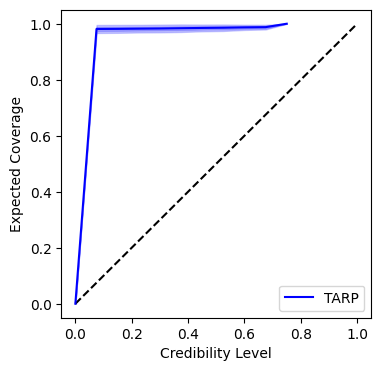

In [8]:
c2st = C2ST_OT_AllParametersPositions_newprior(savedir='./CrossAttentionTransformer/figure/', num_total_samples=400, batch_size=200, observation_idx=100 )
logs = {'posteriors': []}
c2st._call(logs, rng, solver, dataloader_train)